# Evaluación del modelo clasificador de riesgo IA

En este notebook evaluamos el modelo entrenado sobre el conjunto de test.

Métricas:
1. Classification report (precision, recall, f1 por clase)
2. F1-score macro
3. Matriz de confusión
4. Curva ROC multiclase (One-vs-Rest)
5. Análisis de errores
6. Registro de métricas en MLflow

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

# Localizar src/classifier/ de forma robusta y ajustar cwd al directorio
# de este notebook para que rutas relativas (datasets/, data/, model/) funcionen
# independientemente de desde donde se lance Jupyter/VS Code.
_cwd = os.getcwd()
_candidates = [
    os.path.join(_cwd, "src", "classifier"),
    os.path.abspath(".."),
    os.path.abspath("."),
]
for _p in _candidates:
    if os.path.isfile(os.path.join(_p, "functions.py")):
        if _p not in sys.path:
            sys.path.insert(0, _p)
        # Cambiar cwd al directorio de este notebook
        os.chdir(os.path.join(_p, "classifier_dataset_real"))
        break

import functions  # noqa: E402
functions.MLFLOW_EXPERIMENT = "clasificador_riesgo_ia_real"
functions._DATASET_TAGS = {"dataset_type": "real", "dataset_source": "eu_ai_act_flagged"}

## 1. Carga del modelo y datos de test

In [3]:
import os
import pandas as pd
import joblib
from scipy.sparse import csr_matrix, hstack

# Cargar modelo y artefactos del pipeline
modelo = joblib.load("model/modelo_baseline.joblib")
tfidf  = joblib.load("model/tfidf_vectorizer.joblib")
ohe    = joblib.load("model/ohe_encoder.joblib") if os.path.exists("model/ohe_encoder.joblib") else None

print("Artefactos cargados correctamente.")

test_df = pd.read_csv("data/processed/test.csv")
X_test_text = test_df["text_final"]
y_test      = test_df["etiqueta"]

# Construir la misma matriz de features que usó el entrenamiento
X_test_tfidf = tfidf.transform(X_test_text)

if ohe is not None:
    CAT_COLS = ["category", "context"]
    NUM_COLS = ["longitud", "num_articles"]
    cat_test = ohe.transform(test_df[CAT_COLS])
    num_test = csr_matrix(test_df[NUM_COLS].values.astype(float))
    X_test_final = hstack([X_test_tfidf, cat_test, num_test])
    print(f"Pipeline: TF-IDF ({X_test_tfidf.shape[1]}) + OHE ({cat_test.shape[1]}) + numéricas ({len(NUM_COLS)}) = {X_test_final.shape[1]} features")
else:
    X_test_final = X_test_tfidf
    print(f"Pipeline: solo TF-IDF ({X_test_final.shape[1]} features) — ohe_encoder.joblib no encontrado")

print(f"\nTest: {len(X_test_text)} muestras")
print(f"Clases: {sorted(y_test.unique())}")

Artefactos cargados correctamente.
Pipeline: TF-IDF (3773) + OHE (22) + numéricas (2) = 3797 features

Test: 90 muestras
Clases: ['alto_riesgo', 'inaceptable', 'riesgo_limitado', 'riesgo_minimo']


## 2. Classification report y F1-score macro

In [4]:
from functions import evaluar_modelo

y_pred, report_dict = evaluar_modelo(modelo, X_test_final, y_test)

=== Resultados en TEST ===

                 precision    recall  f1-score   support

    alto_riesgo       0.53      0.90      0.67        21
    inaceptable       0.68      0.90      0.78        31
riesgo_limitado       1.00      0.15      0.27        13
  riesgo_minimo       0.82      0.36      0.50        25

       accuracy                           0.64        90
      macro avg       0.76      0.58      0.55        90
   weighted avg       0.73      0.64      0.60        90

F1-score macro (test): 0.5528



## 3. Matriz de confusión

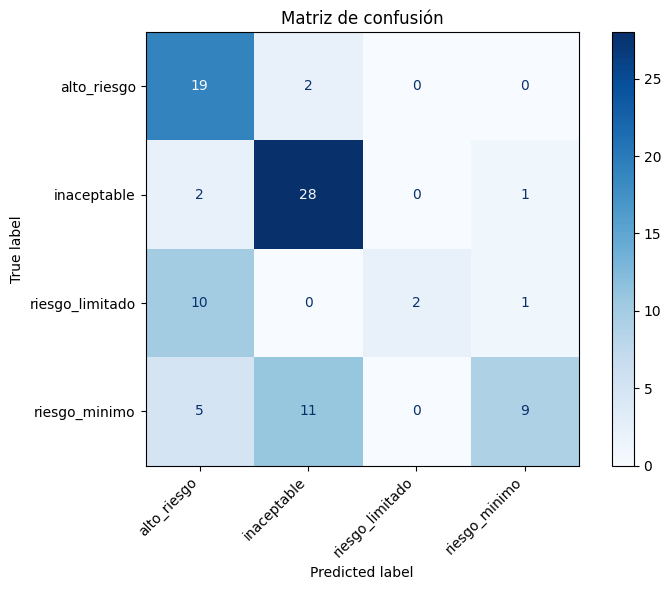

In [5]:
from functions import mostrar_matriz_confusion

clases = sorted(y_test.unique())
fig_cm = mostrar_matriz_confusion(y_test, y_pred, labels=clases)

## 4. Curva ROC multiclase

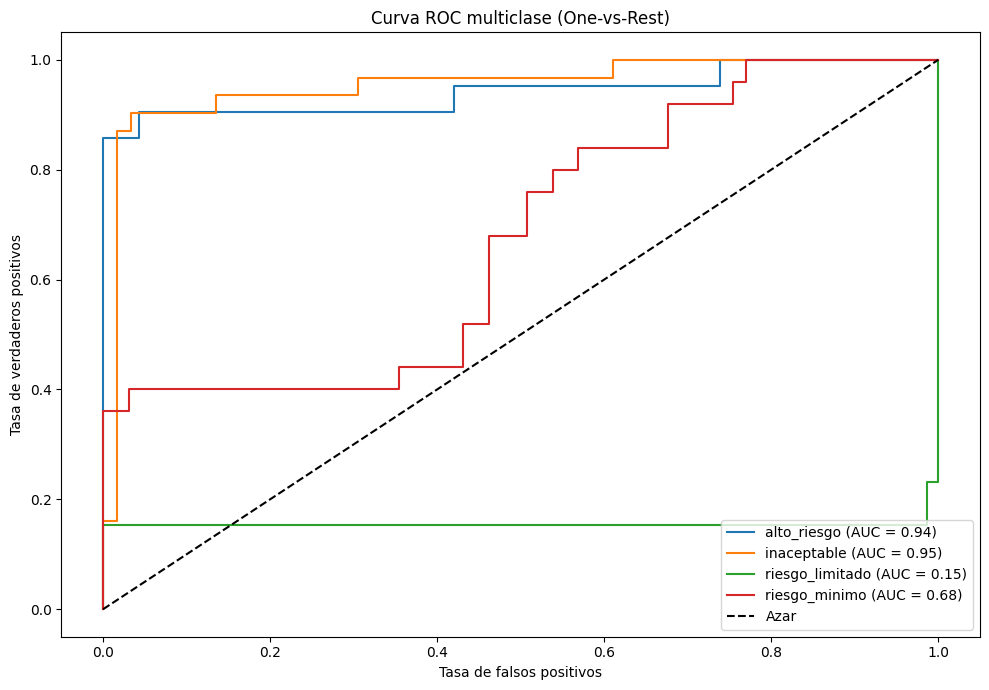


ROC AUC macro: 0.6817
  alto_riesgo: 0.9427
  inaceptable: 0.9530
  riesgo_limitado: 0.1548
  riesgo_minimo: 0.6763


In [6]:
from functions import plot_curva_roc_multiclase

fig_roc, roc_auc_dict = plot_curva_roc_multiclase(modelo, X_test_final, y_test)

## 5. Análisis de errores

In [7]:
from functions import analisis_errores

df_errores = analisis_errores(modelo, X_test_final, y_test, X_test_text=X_test_text)

Total de errores: 32 de 90 (35.6%)

Confusiones más frecuentes:
etiqueta_real    etiqueta_predicha
riesgo_minimo    inaceptable          11
riesgo_limitado  alto_riesgo          10
riesgo_minimo    alto_riesgo           5
alto_riesgo      inaceptable           2
inaceptable      alto_riesgo           2
                 riesgo_minimo         1
riesgo_limitado  riesgo_minimo         1
dtype: int64

Ejemplos mal clasificados:
  Real: riesgo_minimo | Predicho: alto_riesgo
  Texto: herramienta generación respuesta correo electrónico sugerir borrador respuesta usuario basar él contenido mensaje recibi...

  Real: riesgo_minimo | Predicho: inaceptable
  Texto: herramienta asistencia redacción informe anual corporativo sugerir mejora estructura claridad texto modificar contenido ...

  Real: alto_riesgo | Predicho: inaceptable
  Texto: compañía seguro utilizar sistema inteligencia artificial rechazar automáticamente reclamación incidente relacionado salu...

  Real: riesgo_limitado | Predicho:

## 6. Registro de métricas en MLflow

In [8]:
# ── MLflow (solo falla esta celda si el servidor no está disponible) ──
import numpy as np
import mlflow
from functions import configure_mlflow, MLFLOW_EXPERIMENT

# Guardar gráficos localmente (no depende del servidor)
fig_cm.savefig("model/matriz_confusion.png", dpi=150, bbox_inches="tight")
fig_roc.savefig("model/curva_roc.png", dpi=150, bbox_inches="tight")

try:
    configure_mlflow()
    mlflow.set_experiment(MLFLOW_EXPERIMENT)

    with mlflow.start_run(run_name="evaluacion_test"):
        mlflow.log_metric("test_f1_macro",        report_dict["macro avg"]["f1-score"])
        mlflow.log_metric("test_accuracy",         report_dict["accuracy"])
        mlflow.log_metric("test_precision_macro",  report_dict["macro avg"]["precision"])
        mlflow.log_metric("test_recall_macro",     report_dict["macro avg"]["recall"])

        for clase, auc_val in roc_auc_dict.items():
            mlflow.log_metric(f"test_roc_auc_{clase}", auc_val)
        mlflow.log_metric("test_roc_auc_macro", np.mean(list(roc_auc_dict.values())))

        mlflow.log_artifact("model/matriz_confusion.png")
        mlflow.log_artifact("model/curva_roc.png")

        print("✓ Métricas de test registradas en MLflow")
        print(f"  F1-score macro: {report_dict['macro avg']['f1-score']:.4f}")
        print(f"  Run ID: {mlflow.active_run().info.run_id}")
except Exception as e:
    print(f"⚠ MLflow no disponible: {e}")

Password obtenida desde variable de entorno local.
MLflow configurado correctamente → https://18.201.64.41/


c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '18.201.64.41'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '18.201.64.41'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '18.201.64.41'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\r

✓ Métricas de test registradas en MLflow
  F1-score macro: 0.5528
  Run ID: 9e6d6842129b4468b2913a13c0b82431


c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '18.201.64.41'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Instala las dependencias desde `requirements.txt` antes de ejecutar este notebook:
```bash
pip install -r requirements.txt
```

## 7. Conclusiones

Documentar aquí las conclusiones tras observar las métricas:
- ¿Qué clases se confunden más entre sí?
- ¿El modelo generaliza bien o muestra signos de overfitting?
- ¿Qué mejoras se podrían probar en iteraciones futuras?